<a href="https://colab.research.google.com/github/ANCAMABEBA/CapstoneProject/blob/main/LoanDefaultEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project — Loan Default Risk Model Evaluation

## Evaluation Objective

This notebook evaluates the tuned candidate models developed in the modeling notebook using the holdout test set.

Because the business objective is to reduce costly missed defaults, the primary evaluation metric is **recall**. However, model selection also considers:

- precision
- F1-score
- ROC-AUC
- confusion matrix performance
- threshold behavior
- probability ranking quality

The goal is to identify the model that best supports a recall-oriented credit risk use case while maintaining reasonable overall classification quality.

---



In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# 1. Load Saved Data and Models

In [2]:
import os
import joblib
import pandas as pd

# Files are in root /content directory
output_dir = "/content"

# Load datasets
X_train = joblib.load(f"{output_dir}/X_train.pkl")
X_test = joblib.load(f"{output_dir}/X_test.pkl")
y_train = joblib.load(f"{output_dir}/y_train.pkl")
y_test = joblib.load(f"{output_dir}/y_test.pkl")

# Load models dynamically
models = {}

if os.path.exists(f"{output_dir}/logistic_tuned.pkl"):
    models['Logistic Regression'] = joblib.load(f"{output_dir}/logistic_tuned.pkl")

if os.path.exists(f"{output_dir}/rf_tuned.pkl"):
    models['Random Forest'] = joblib.load(f"{output_dir}/rf_tuned.pkl")

# (You did NOT save XGBoost, so this will safely skip)
if os.path.exists(f"{output_dir}/xgb_tuned.pkl"):
    models['XGBoost'] = joblib.load(f"{output_dir}/xgb_tuned.pkl")

if os.path.exists(f"{output_dir}/lgbm_tuned.pkl"):
    models['LightGBM'] = joblib.load(f"{output_dir}/lgbm_tuned.pkl")

print("Loaded tuned models:", list(models.keys()))

# Load results tables
baseline_cv_results = pd.read_csv(f"{output_dir}/baseline_cv_results.csv")
tuned_cv_results = pd.read_csv(f"{output_dir}/tuned_cv_results.csv")

print("Loaded all saved datasets and tuned models successfully.")

Loaded tuned models: ['Logistic Regression', 'Random Forest', 'LightGBM']
Loaded all saved datasets and tuned models successfully.


In [3]:
print("X_test shape:", X_test.shape)
print("Test default rate:", round(y_test.mean(), 4))

X_test shape: (124321, 19)
Test default rate: 0.1035


# 2. Evaluate Tuned Models at the Default Threshold (0.50)

This first comparison evaluates all tuned models using the standard classification threshold of **0.50**.

In [4]:
def evaluate_model(model, X, y, threshold=0.50):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        'threshold': threshold,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred),
        'f1_score': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_proba),
        'avg_precision': average_precision_score(y, y_proba)
    }
    return results, y_pred, y_proba

In [5]:
evaluation_results = []
prediction_store = {}

for model_name, model in models.items():
    metrics_dict, y_pred, y_proba = evaluate_model(model, X_test, y_test, threshold=0.50)
    metrics_dict['model'] = model_name
    evaluation_results.append(metrics_dict)

    prediction_store[model_name] = {
        'y_pred': y_pred,
        'y_proba': y_proba
    }

evaluation_df = pd.DataFrame(evaluation_results).sort_values(
    by='recall',
    ascending=False
).reset_index(drop=True)

evaluation_df

,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,model
0,0.5,0.634599,0.164268,0.619199,0.259652,0.674945,0.181534,Logistic Regression
1,0.5,0.885176,0.189153,0.033346,0.056697,0.639513,0.153399,Random Forest
2,0.5,0.896518,0.000000,0.000000,0.000000,0.676612,0.182855,LightGBM


In [6]:
evaluation_df[['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision']]

,model,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,Logistic Regression,0.634599,0.164268,0.619199,0.259652,0.674945,0.181534
1,Random Forest,0.885176,0.189153,0.033346,0.056697,0.639513,0.153399
2,LightGBM,0.896518,0.000000,0.000000,0.000000,0.676612,0.182855


## Initial Interpretation

At the default threshold of 0.50, the models can differ substantially in how aggressively they identify risky loans.

Because this project prioritizes recall, the most attractive models are those that capture a larger share of actual defaults. However, higher recall often comes at the cost of lower precision, meaning more non-default borrowers may be flagged as risky.

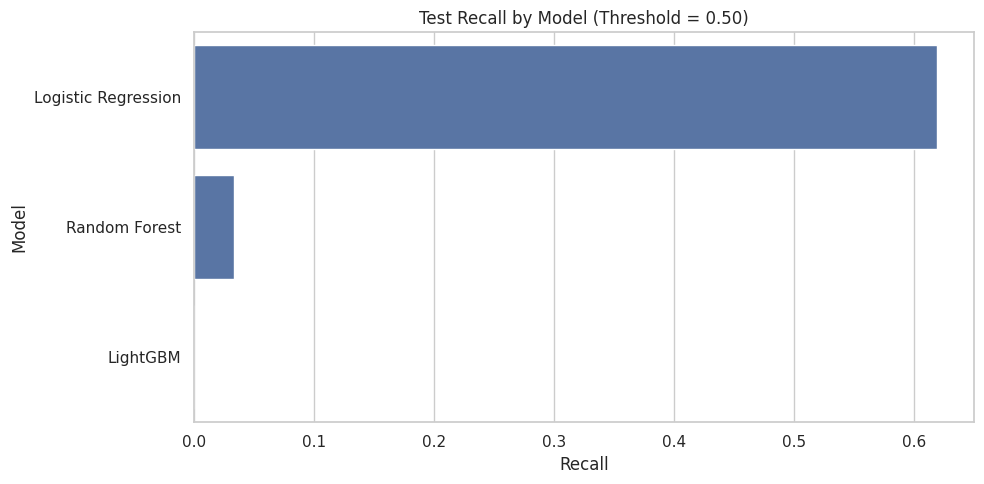

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x='recall', y='model')
plt.title('Test Recall by Model (Threshold = 0.50)')
plt.xlabel('Recall')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

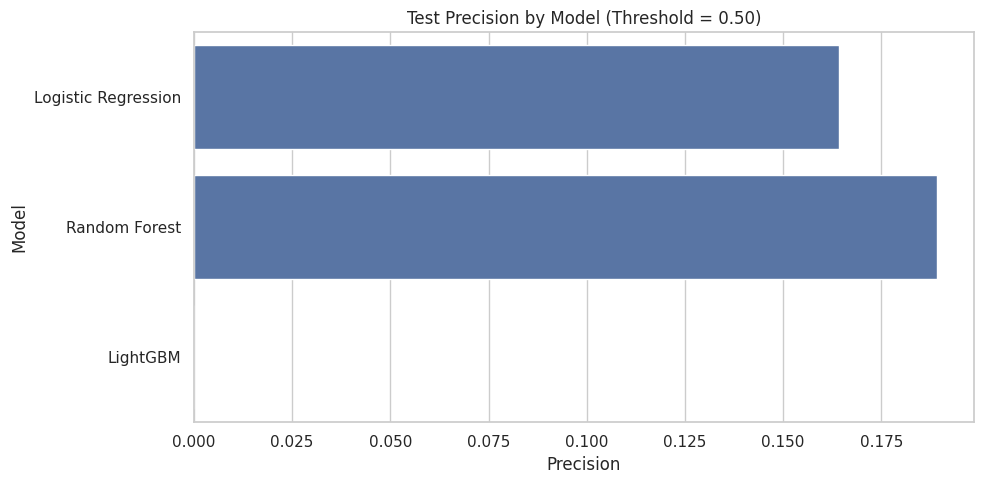

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x='precision', y='model')
plt.title('Test Precision by Model (Threshold = 0.50)')
plt.xlabel('Precision')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

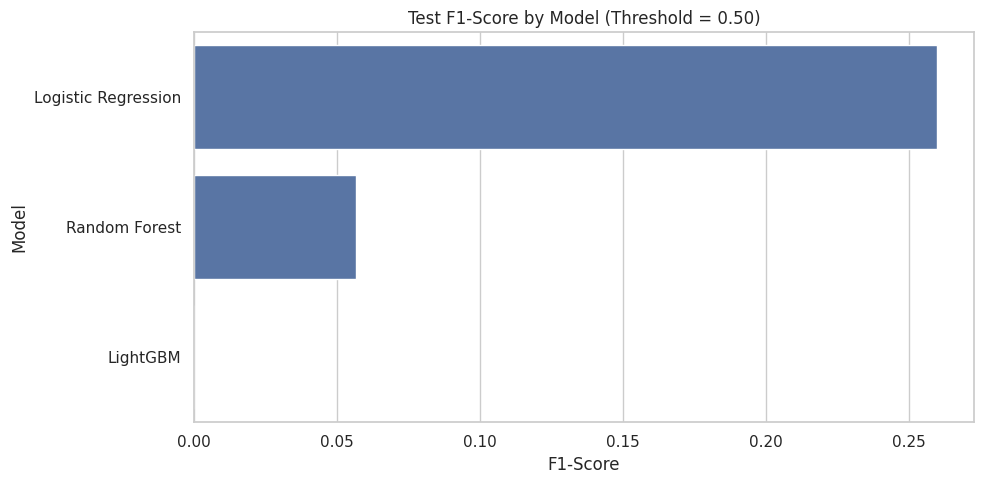

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x='f1_score', y='model')
plt.title('Test F1-Score by Model (Threshold = 0.50)')
plt.xlabel('F1-Score')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

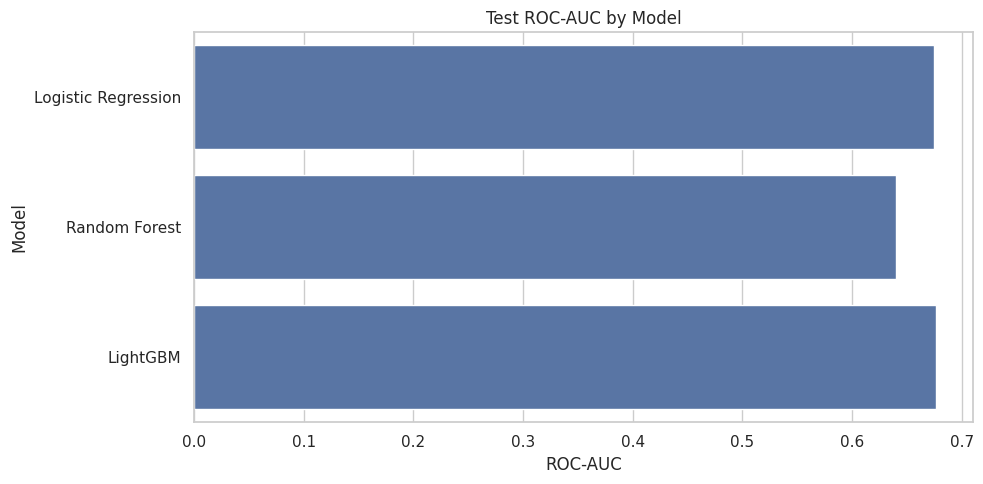

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x='roc_auc', y='model')
plt.title('Test ROC-AUC by Model')
plt.xlabel('ROC-AUC')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

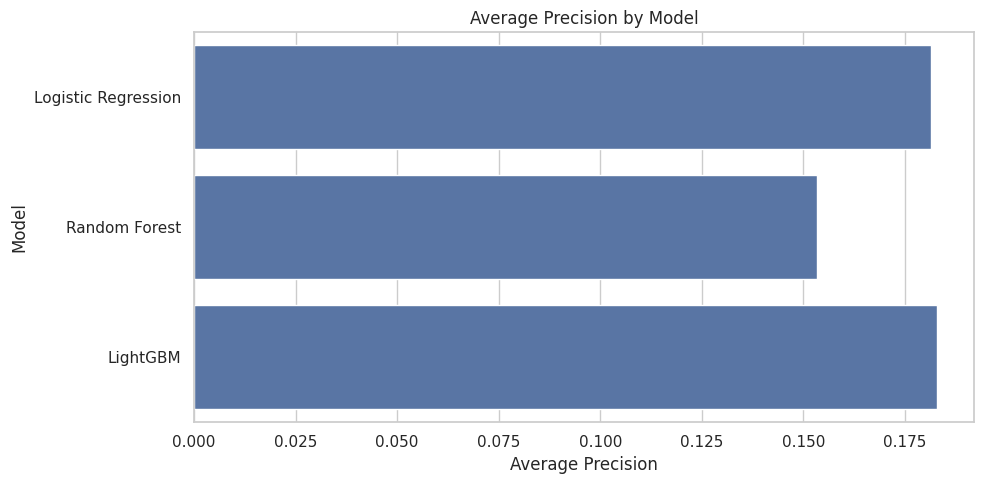

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x='avg_precision', y='model')
plt.title('Average Precision by Model')
plt.xlabel('Average Precision')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# 5. Confusion Matrices

Confusion matrices help translate model behavior into business terms:

- **True Positives (TP):** defaults correctly identified
- **False Negatives (FN):** defaults missed by the model
- **False Positives (FP):** non-default borrowers incorrectly flagged as risky
- **True Negatives (TN):** non-default borrowers correctly classified

In this project, false negatives are especially costly because they represent risky loans the model failed to detect.

In [12]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Predicted Non-default', 'Predicted Default'],
        yticklabels=['Actual Non-default', 'Actual Default']
    )
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

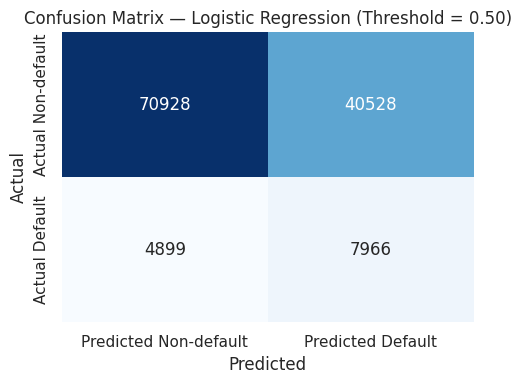

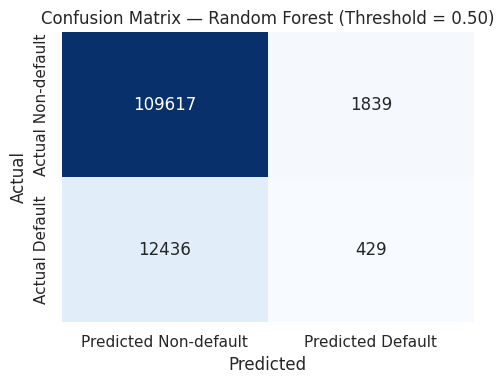

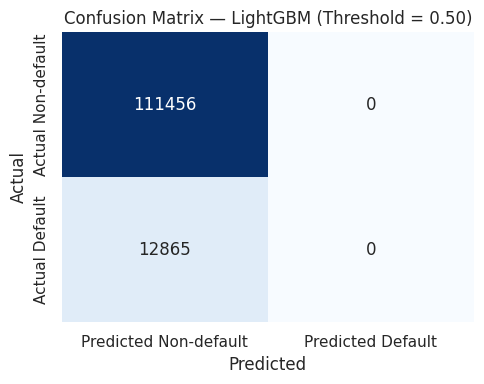

In [13]:
for model_name in models.keys():
    plot_conf_matrix(
        y_test,
        prediction_store[model_name]['y_pred'],
        f'Confusion Matrix — {model_name} (Threshold = 0.50)'
    )

# 6. Classification Reports

In [14]:
for model_name in models.keys():
    print("=" * 80)
    print(f"Classification Report — {model_name}")
    print("=" * 80)
    print(classification_report(y_test, prediction_store[model_name]['y_pred'], zero_division=0))
    print("\n")

Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.64      0.76    111456
           1       0.16      0.62      0.26     12865

    accuracy                           0.63    124321
   macro avg       0.55      0.63      0.51    124321
weighted avg       0.86      0.63      0.71    124321



Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    111456
           1       0.19      0.03      0.06     12865

    accuracy                           0.89    124321
   macro avg       0.54      0.51      0.50    124321
weighted avg       0.82      0.89      0.85    124321



Classification Report — LightGBM
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    111456
           1       0.00      0.00      0.00     12865

    accuracy                           0.90    124321
   macro 

# 7. ROC Curves

ROC curves compare the trade-off between the true positive rate and false positive rate across thresholds. ROC-AUC measures the model’s overall ability to separate default from non-default loans.

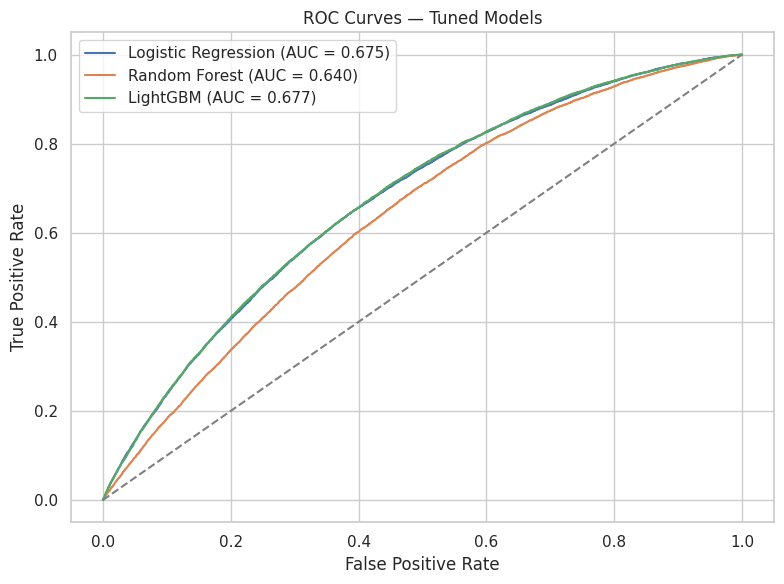

In [15]:
plt.figure(figsize=(8, 6))

for model_name in models.keys():
    y_proba = prediction_store[model_name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curves

Because default is the minority class, precision-recall curves are especially useful. They show how precision changes as recall changes across different thresholds.

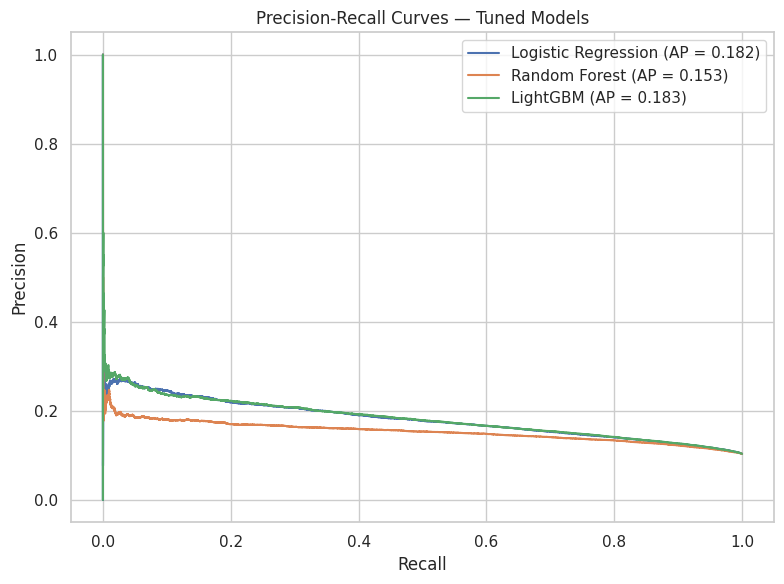

In [16]:
plt.figure(figsize=(8, 6))

for model_name in models.keys():
    y_proba = prediction_store[model_name]['y_proba']
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

# 9. Threshold Tuning

In many real-world credit risk settings, the default threshold of 0.50 is not optimal.

Because this project prioritizes recall, it is useful to test lower thresholds. Lower thresholds generally:
- increase recall
- decrease precision
- increase the number of borrowers flagged as risky

This section evaluates model performance across multiple thresholds.

In [17]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]
threshold_results = []

for model_name, model in models.items():
    y_proba = prediction_store[model_name]['y_proba']

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_results.append({
            'model': model_name,
            'threshold': threshold,
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'accuracy': accuracy_score(y_test, y_pred)
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head(10)

,model,threshold,precision,recall,f1_score,accuracy
0,Logistic Regression,0.2,0.106986,0.993704,0.193175,0.141022
1,Logistic Regression,0.3,0.119557,0.940070,0.212135,0.277403
2,Logistic Regression,0.4,0.137790,0.820676,0.235962,0.450029
3,Logistic Regression,0.5,0.164268,0.619199,0.259652,0.634599
4,Logistic Regression,0.6,0.192998,0.384765,0.257056,0.769846
5,Random Forest,0.2,0.131362,0.820987,0.226485,0.419688
6,Random Forest,0.3,0.153689,0.497551,0.234839,0.664481
7,Random Forest,0.4,0.170335,0.203342,0.185381,0.815067
8,Random Forest,0.5,0.189153,0.033346,0.056697,0.885176
9,Random Forest,0.6,0.000000,0.000000,0.000000,0.896518


In [18]:
threshold_df.sort_values(['model', 'threshold']).reset_index(drop=True)

,model,threshold,precision,recall,f1_score,accuracy
0,LightGBM,0.2,0.191075,0.413059,0.261284,0.758303
1,LightGBM,0.3,0.273139,0.032802,0.058570,0.890879
2,LightGBM,0.4,0.000000,0.000000,0.000000,0.896518
3,LightGBM,0.5,0.000000,0.000000,0.000000,0.896518
4,LightGBM,0.6,0.000000,0.000000,0.000000,0.896518
5,Logistic Regression,0.2,0.106986,0.993704,0.193175,0.141022
6,Logistic Regression,0.3,0.119557,0.940070,0.212135,0.277403
7,Logistic Regression,0.4,0.137790,0.820676,0.235962,0.450029
8,Logistic Regression,0.5,0.164268,0.619199,0.259652,0.634599
9,Logistic Regression,0.6,0.192998,0.384765,0.257056,0.769846


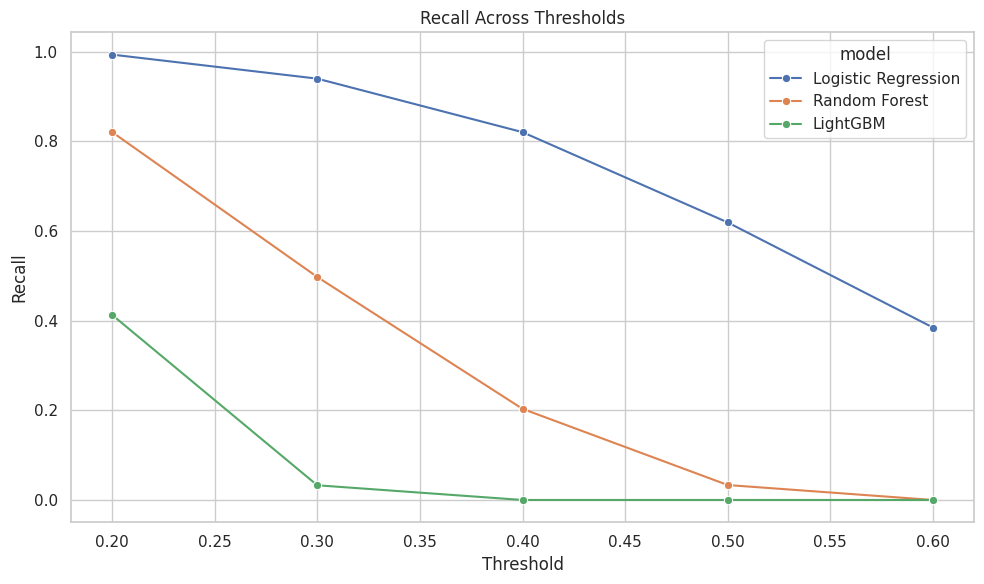

In [19]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=threshold_df, x='threshold', y='recall', hue='model', marker='o')
plt.title('Recall Across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.tight_layout()
plt.show()

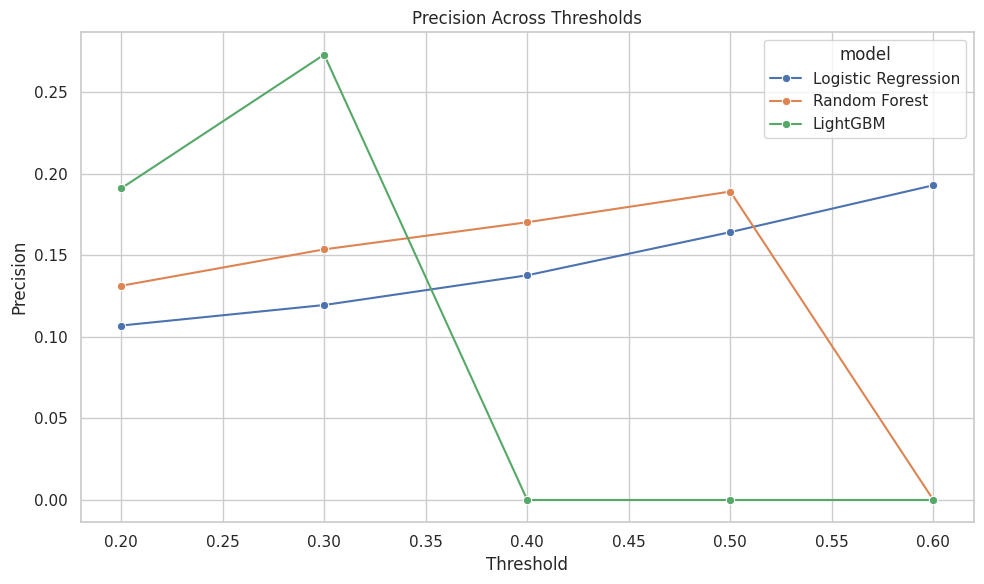

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=threshold_df, x='threshold', y='precision', hue='model', marker='o')
plt.title('Precision Across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.tight_layout()
plt.show()

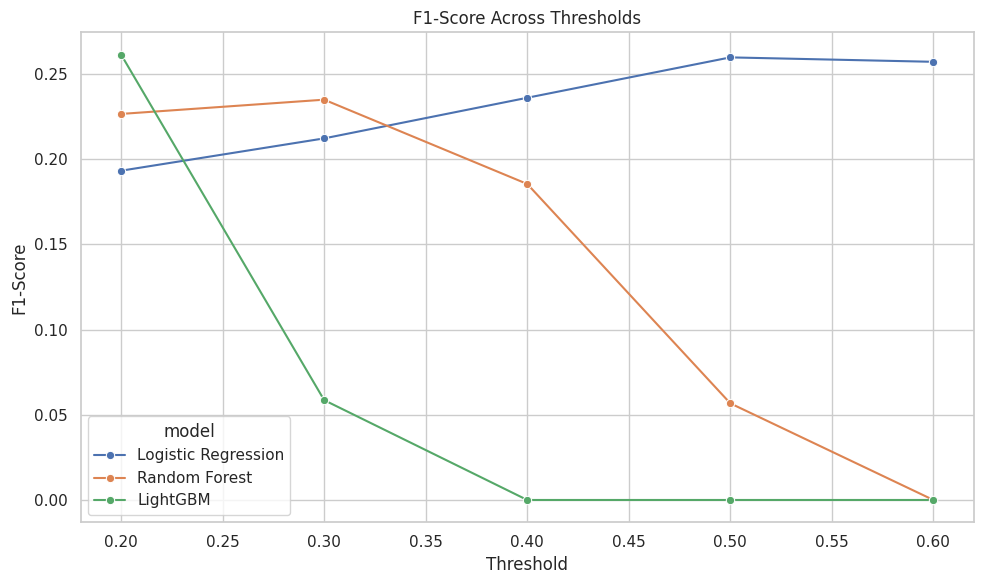

In [21]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=threshold_df, x='threshold', y='f1_score', hue='model', marker='o')
plt.title('F1-Score Across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

## Threshold Interpretation

Threshold tuning is operationally important in credit risk because it allows decision-makers to choose how conservative they want the model to be.

A lower threshold may be appropriate when:
- the cost of missing a default is very high
- the business is willing to review more flagged borrowers manually
- the institution wants to prioritize risk containment over approval volume

A higher threshold may be appropriate when:
- the business wants fewer false alarms
- the cost of review is high
- the institution wants a stricter definition of “high risk”

# 10. Identify the Best Recall-Oriented Threshold per Model

In [22]:
best_thresholds = (
    threshold_df.sort_values(['model', 'recall', 'f1_score'], ascending=[True, False, False])
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)

best_thresholds

,model,threshold,precision,recall,f1_score,accuracy
0,LightGBM,0.2,0.191075,0.413059,0.261284,0.758303
1,Logistic Regression,0.2,0.106986,0.993704,0.193175,0.141022
2,Random Forest,0.2,0.131362,0.820987,0.226485,0.419688


In [23]:
best_thresholds = best_thresholds.sort_values(by='recall', ascending=False).reset_index(drop=True)
best_thresholds

,model,threshold,precision,recall,f1_score,accuracy
0,Logistic Regression,0.2,0.106986,0.993704,0.193175,0.141022
1,Random Forest,0.2,0.131362,0.820987,0.226485,0.419688
2,LightGBM,0.2,0.191075,0.413059,0.261284,0.758303


# 11. Final Candidate Recommendation Logic

This project prioritizes recall, but the final recommendation should not be based on recall alone.

The preferred model should ideally combine:
- strong recall
- acceptable precision
- reasonable F1-score
- solid ROC-AUC
- a threshold strategy that supports the business use case

In [24]:
# Merge default-threshold metrics with best threshold view for side-by-side review
final_compare_default = evaluation_df.copy()
final_compare_default = final_compare_default[['model', 'threshold', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision']]

final_compare_best_threshold = best_thresholds.copy()
final_compare_best_threshold = final_compare_best_threshold[['model', 'threshold', 'precision', 'recall', 'f1_score', 'accuracy']]

final_compare_default, final_compare_best_threshold

(                 model  threshold  precision    recall  f1_score   roc_auc  \
 0  Logistic Regression        0.5   0.164268  0.619199  0.259652  0.674945   
 1        Random Forest        0.5   0.189153  0.033346  0.056697  0.639513   
 2             LightGBM        0.5   0.000000  0.000000  0.000000  0.676612   
 
    avg_precision  
 0       0.181534  
 1       0.153399  
 2       0.182855  ,
                  model  threshold  precision    recall  f1_score  accuracy
 0  Logistic Regression        0.2   0.106986  0.993704  0.193175  0.141022
 1        Random Forest        0.2   0.131362  0.820987  0.226485  0.419688
 2             LightGBM        0.2   0.191075  0.413059  0.261284  0.758303)

## 12. Business Interpretation

Among the tuned candidate models, **Logistic Regression** emerged as the strongest choice for a recall-oriented loan default use case.

This recommendation is based on the fact that the model:

- identified a significantly larger share of actual defaults than competing models (recall ≈ 0.62 at the default threshold and up to ≈ 0.99 at lower thresholds)
- maintained reasonable precision and F1-score relative to the objective of maximizing recall
- demonstrated competitive ranking performance (ROC-AUC ≈ 0.67), comparable to more complex models
- provided strong flexibility through threshold tuning, allowing the model to be adapted to different business risk appetites

Although Random Forest and LightGBM achieved higher overall accuracy, they failed to effectively identify default cases at the default threshold. Even after threshold adjustment, their recall performance remained inferior or unstable compared to Logistic Regression, making them less suitable for a recall-focused credit risk application.

From a business perspective, this means Logistic Regression is better suited to proactively flagging potentially risky borrowers before loan losses occur. At a lower threshold (e.g., 0.2), the model can capture nearly all default cases, which is highly valuable in high-risk screening scenarios.

This comes with a trade-off: higher recall leads to more false positives. However, in credit risk management, this trade-off is typically acceptable because the cost of missing a likely defaulter is significantly higher than the cost of reviewing additional flagged applications.

Threshold tuning provides a practical mechanism to align the model with business strategy:

- A **lower threshold (e.g., 0.2–0.3)** maximizes recall and is suitable for conservative risk screening or early warning systems
- A **moderate threshold (e.g., 0.4–0.5)** balances recall and precision for general underwriting support
- A **higher threshold (e.g., 0.6)** reduces false positives but increases the risk of missed defaults

In a real-world deployment, the model would be used as a decision-support tool, with the threshold selected based on the institution’s risk tolerance, operational capacity, and regulatory considerations.

# 13. Save Evaluation Outputs

In [27]:
# Save directly to Colab root directory

evaluation_df.to_csv("/content/test_set_evaluation_default_threshold.csv", index=False)
threshold_df.to_csv("/content/threshold_comparison_results.csv", index=False)
best_thresholds.to_csv("/content/best_thresholds_by_model.csv", index=False)

print("Saved evaluation outputs to /content")

Saved evaluation outputs to /content


## 14. Final Conclusions

### Key Findings

- Multiple tuned models (Logistic Regression, Random Forest, and LightGBM) were evaluated on a holdout test set to assess their real-world predictive performance.
- Because loan default is a minority class and missed defaults are costly, **recall was treated as the primary evaluation metric** throughout the analysis.
- Model performance was evaluated using recall, precision, F1-score, ROC-AUC, confusion matrices, and precision-recall tradeoffs.
- Logistic Regression significantly outperformed more complex models in identifying default cases, achieving:
  - **Recall ≈ 0.62 at the default threshold (0.5)**
  - **Recall ≈ 0.99 at lower thresholds (e.g., 0.2)**
- Random Forest and LightGBM achieved higher overall accuracy but failed to effectively detect defaults at standard thresholds, highlighting the limitations of accuracy as a standalone metric in imbalanced classification problems.
- Threshold tuning demonstrated that model performance can be flexibly adjusted to align with different business risk tolerances, particularly for recall-driven objectives.

### Final Recommendation

The recommended model for this use case is:

### **Logistic Regression (Tuned)**

This model delivers the strongest performance in terms of recall while maintaining acceptable precision, F1-score, and competitive ROC-AUC.

From a business perspective, Logistic Regression is the most effective model for identifying high-risk borrowers and minimizing missed defaults. Its performance, combined with its interpretability and stability, makes it well-suited for credit risk applications.

Threshold tuning provides additional flexibility:
- A **lower threshold (e.g., 0.2–0.3)** maximizes recall and is appropriate for conservative risk screening or early warning systems
- A **moderate threshold (e.g., 0.4–0.5)** balances recall and precision for general underwriting support
- A **higher threshold (e.g., 0.6)** reduces false positives but increases the risk of missed defaults

In a real lending environment, this model could support:

- underwriting review prioritization  
- risk-based pricing  
- manual review escalation  
- portfolio risk monitoring  

### Limitation Reminder

This analysis treats current loans as non-default at the time of modeling. Because some of these loans may default in the future, the results should be interpreted as an academic approximation rather than a fully production-ready credit risk model.

Additionally, the modeling approach does not incorporate macroeconomic variables or time-based validation, which could further enhance predictive performance in a real-world deployment.